In [70]:
import pandas as pd
import geopandas as gpd
import maup
import time
from maup import smart_repair
from gerrychain import Graph

maup.progress.enabled = True

In [71]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# state = Massachusetts
state_ab = "nv"

## Data
1. Download all the data in directory "ma_data"
2. Extract them all

In [73]:
population1_data = "{}_pl2020_b/{}_pl2020_p1_b.shp".format( state_ab, state_ab)
population2_data = "{}_pl2020_b/{}_pl2020_p2_b.shp".format(state_ab, state_ab)
vap_data =  "{}_pl2020_b/{}_pl2020_p4_b.shp".format( state_ab, state_ab)
vest20_data = "{}_vest_20/{}_vest_20.shp".format( state_ab, state_ab)
vest18_data = "{}_vest_18/{}_vest_18.shp".format( state_ab, state_ab)
vest16_data = "{}_vest_16/{}_vest_16.shp".format(state_ab, state_ab)
cd_data = "{}_cong_2021/ma_cong_2021.shp".format( state_ab)
send_data = "{}_sldu_2021/ma_sldu_2021.shp".format( state_ab)
hdist_data = "{}_sldl_2021/ma_sldl_2021.shp".format( state_ab)
county_data = "{}_pl2020_cnty/{}_pl2020_cnty.shp".format( state_ab, state_ab)

In [74]:
def do_smart_repair(df, min_rook_length = None, snap_precision = 10):
    # change it to the UTM it needs for smart_repair
    df = df.to_crs(df.estimate_utm_crs())
    df = smart_repair(df, min_rook_length = min_rook_length, snap_precision = snap_precision)

    if maup.doctor(df) == False:
        print("Maup doctor failed!  Take a look")
        #raise Exception('maup.doctor failed')
    
    return df

In [75]:
def add_district(dist_df, dist_name, election_df, col_name):
    election_df = election_df.to_crs(election_df.estimate_utm_crs())
    dist_df = dist_df.to_crs(dist_df.estimate_utm_crs())
    # check if it needs to be smart_repair
    if maup.doctor(dist_df) != True:
        dist_df = do_smart_repair(dist_df)

    # assign the pricincts
    precincts_to_district_assignment = maup.assign(election_df.geometry, dist_df.geometry)
    election_df[dist_name] = precincts_to_district_assignment
    for precinct_index in range(len(election_df)):
        election_df.at[precinct_index, dist_name] = dist_df.at[election_df.at[precinct_index, dist_name], col_name]

    return election_df

In [76]:
def rename(original, year):
    party = original[6]
    if party == 'R' or party == 'D':
        return original[3:6] + year + original[6]
    else:
        return original[3:6] + year + 'O'

In [77]:
pop_col = ['TOTPOP', 'HISP', 'NH_WHITE', 'NH_BLACK', 'NH_AMIN', 'NH_ASIAN', 'NH_NHPI', 'NH_OTHER', 'NH_2MORE', 'H_WHITE', 'H_BLACK', 'H_AMIN', 'H_ASIAN', 'H_NHPI', 'H_OTHER', 'H_2MORE', 'VAP', 'HVAP', 'WVAP', 'BVAP', 'AMINVAP', 'ASIANVAP', 'NHPIVAP', 'OTHERVAP', '2MOREVAP']

In [78]:
def check_population(population, df):
    pop_check = pd.DataFrame({
        'pop_col': pop_col,
        'population_df': population[pop_col].sum(), 
        'vest_base': df[pop_col].sum(),
        'equal': [x == y for x, y in zip(population[pop_col].sum(), df[pop_col].sum())]
    })
    if pop_check['equal'].mean() < 1:
        print(pop_check)
        raise Exception("population doesn't agree")

    else:
        print("population agrees")

In [79]:
def add_vest(vest, df, year, population, start_col, snap_precision = 10):
    df = df.to_crs(df.estimate_utm_crs())
    vest = vest.to_crs(vest.estimate_utm_crs())
    population = population.to_crs(population.estimate_utm_crs())
    df_crs = df.crs
    vest_crs = vest.crs
    
     # check if it needs to be smart_repair
    if maup.doctor(vest) != True:
        vest = do_smart_repair(vest, snap_precision = snap_precision)
    
    # rename the columns
    original_col = vest.columns[start_col:-1]
    new_col = [rename(i, year) for i in original_col]
    rename_dict = dict(zip(original_col, new_col))
    vest = vest.rename(columns=rename_dict)
    vest = vest.groupby(level=0, axis=1).sum() # combine all the other party's vote into columns with sufix "O"
    col_name = list(set(new_col))
    col_name.sort()
    
    # make the blocks from precincts by weight
    vest = gpd.GeoDataFrame(vest, crs=vest_crs)
    election_in_block = population[["VAP", 'geometry']] # population_df is in block scale
    blocks_to_precincts_assignment = maup.assign(election_in_block.geometry, vest.geometry)
    weights = election_in_block["VAP"] / blocks_to_precincts_assignment.map(election_in_block["VAP"].groupby(blocks_to_precincts_assignment).sum())
    weights = weights.fillna(0)
    prorated = maup.prorate(blocks_to_precincts_assignment, vest[col_name], weights)
    election_in_block[col_name] = prorated
    
    # assign blocks to precincts
    election_in_block = gpd.GeoDataFrame(election_in_block, crs=vest_crs)
    df = gpd.GeoDataFrame(df, crs=df_crs)
    block_to_pricinct_assginment = maup.assign(election_in_block.geometry, df.geometry)
    df[col_name] = election_in_block[col_name].groupby(block_to_pricinct_assginment).sum()
    df = df.groupby(level=0, axis=1).sum()
    df = gpd.GeoDataFrame(df, crs = df_crs)
    # check if population agrees
    check_population(population, df)
    
    return df

In [80]:
def add_vest_base(vest, start_col, year, county = None, min_rook_length = None, snap_precision = 10):
    vest = vest.to_crs(vest.estimate_utm_crs())
    vest_crs = vest.crs
    original_col = vest.columns[start_col:-1]
    new_col = [rename(i, year) for i in original_col]
    rename_dict = dict(zip(original_col, new_col))
    vest = vest.rename(columns=rename_dict)
    vest = vest.groupby(level=0, axis=1).sum()
    vest = gpd.GeoDataFrame(vest, crs=vest_crs)

    if county is not None:
        county = county.to_crs(county.estimate_utm_crs())
        vest = smart_repair(vest, nest_within_regions = county, min_rook_length = min_rook_length, snap_precision = snap_precision) # nest precincts within counties

    else:
        vest = smart_repair(vest, min_rook_length = min_rook_length, snap_precision = snap_precision) 
    
    return vest

In [81]:
def check_small_boundary_lengths(vest_base):
    import copy
    vest_base = vest_base.to_crs(vest_base.estimate_utm_crs())

    boundaries = copy.deepcopy(vest_base)
    boundaries["geometry"] = boundaries.geometry.boundary  # get boundaries
    neighbors = gpd.sjoin(boundaries, vest_base, predicate="intersects") # find boundaries that intersect
    neighbors = neighbors[neighbors.index != neighbors.index_right] # remove boundaries of a region with itself

    # compute shared border length using intersection
    borders = list(neighbors.apply(
        lambda row: row.geometry.intersection(vest_base.loc[row.index_right, "geometry"]).length, axis=1
    ))

    borders.sort()
    
    return borders

### Read the census data

In [82]:
population1_df = gpd.read_file(population1_data)
population2_df = gpd.read_file(population2_data)
vap_df = gpd.read_file(vap_data)
county_df = gpd.read_file(county_data)

In [83]:
population2_df = population2_df.drop(columns=['SUMLEV', 'LOGRECNO', 'GEOID', 'COUNTY', 'geometry'])
vap_df = vap_df.drop(columns=['SUMLEV', 'LOGRECNO', 'GEOID', 'COUNTY', 'geometry'])

In [84]:
population_df = pd.merge(population1_df, population2_df, on='GEOID20')
population_df = pd.merge(population_df, vap_df, on='GEOID20')
population_df = population_df.to_crs(population_df.estimate_utm_crs())

In [85]:
maup.doctor(population_df)

100%|██████████| 107278/107278 [00:33<00:00, 3189.29it/s]


True

In [86]:
population_df['H_WHITE'] = population_df.apply(lambda t: t['P0010003'] - t['P0020005'], 1)
population_df['H_BLACK'] = population_df.apply(lambda t: t['P0010004'] - t['P0020006'], 1)
population_df['H_AMIN'] = population_df.apply(lambda t: t['P0010005'] - t['P0020007'], 1)
population_df['H_ASIAN'] = population_df.apply(lambda t: t['P0010006'] - t['P0020008'], 1)
population_df['H_NHPI'] = population_df.apply(lambda t: t['P0010007'] - t['P0020009'], 1)
population_df['H_OTHER'] = population_df.apply(lambda t: t['P0010008'] - t['P0020010'], 1)
population_df['H_2MORE'] = population_df.apply(lambda t: t['P0010009'] - t['P0020011'], 1)

In [87]:
rename_dict = {'P0020001': 'TOTPOP', 'P0020002': 'HISP', 'P0020005': 'NH_WHITE', 'P0020006': 'NH_BLACK', 'P0020007': 'NH_AMIN',
                    'P0020008': 'NH_ASIAN', 'P0020009': 'NH_NHPI', 'P0020010': 'NH_OTHER', 'P0020011': 'NH_2MORE',
                    'P0040001': 'VAP', 'P0040002': 'HVAP', 'P0040005': 'WVAP', 'P0040006': 'BVAP', 'P0040007': 'AMINVAP',
                                        'P0040008': 'ASIANVAP', 'P0040009': 'NHPIVAP', 'P0040010': 'OTHERVAP', 'P0040011': '2MOREVAP'}

In [88]:
population_df.rename(columns=rename_dict, inplace = True)

In [89]:
county_df = county_df.to_crs(county_df.estimate_utm_crs())
maup.doctor(county_df)

100%|██████████| 14/14 [00:00<00:00, 325.66it/s]


True

###### Read the vest 20 data

Now using it as a "base pricinct"

###### Check if vest20 can be used as base

In [90]:
vest20 = gpd.read_file(vest20_data)

In [91]:
vest20.columns

Index(['WP_NAME', 'WARD', 'PRECINCT', 'DISTRICT', 'TOWN', 'TOWN_ID',
       'G20PREDBID', 'G20PRERTRU', 'G20PRELJOR', 'G20PREGHAW', 'G20PREOWRI',
       'G20USSDMAR', 'G20USSROCO', 'G20USSOAYY', 'G20USSOWRI', 'geometry'],
      dtype='object')

In [92]:
start_col = 6
vest_base_data = vest20
year = '20'

In [93]:
vest_base = add_vest_base(vest_base_data, start_col, year, county = county_df)

100%|██████████| 14/14 [00:00<00:00, 342.07it/s]


Snapping all geometries to a grid with precision 10^( -5 ) to avoid GEOS errors.


100%|██████████| 14/14 [00:00<00:00, 93.01it/s]


Identifying overlaps...


100%|██████████| 6368/6368 [00:01<00:00, 5674.85it/s]


...

Gaps to simplify in region 9: 100%|██████████| 4/4 [00:00<00:00, 30.34it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to fill in region 11: 100%|██████████| 43/43 [00:00<00:00, 112.27it/s]


2 gaps in region 12 will remain unfilled, because they exceed the area threshold.
1 gaps in region 12 will remain unfilled, because they are not simply connected.


Gaps to simplify in region 12: 98it [00:02, 44.17it/s]                        
Gaps to fill in region 12: 100%|██████████| 93/93 [00:00<00:00, 108.76it/s]


3 gaps in region 13 will remain unfilled, because they exceed the area threshold.


Gaps to fill in region 13: 100%|██████████| 164/164 [00:03<00:00, 53.43it/s]

In [94]:
borders = check_small_boundary_lengths(vest_base)
print(borders[500:1500])

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0031361901227752787, 0.0031361901227752787, 0.009671526826657601, 0.009671526826657601, 0.019558334224004697, 0.019558334224004697, 0.07010870574094012, 0.07010870574094012, 0.10124683964987137, 0.10124683964987137, 2.0807295689534455, 2.0807295689534455, 2.1170191980051944, 2.1170191980051944, 2.6193286928701274, 2.6193286928701274, 2.712100641

In [95]:
vest_base = do_smart_repair(vest_base, min_rook_length = 30.5)

Snapping all geometries to a grid with precision 10^( -5 ) to avoid GEOS errors.
Identifying overlaps...


100%|██████████| 2628/2628 [00:00<00:00, 9931.00it/s]


Resolving overlaps...
1 gaps will remain unfilled, because they exceed the area threshold.
5 gaps will remain unfilled, because they are not simply connected.
Filling gaps...


Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]


Converting small rook adjacencies to queen...


100%|██████████| 2173/2173 [00:01<00:00, 1868.67it/s]


There are 6 holes.
Maup doctor failed!  Take a look


In [96]:
maup.doctor(vest_base)

100%|██████████| 2173/2173 [00:01<00:00, 1870.14it/s]


There are 6 holes.


False

There are still holes!  If the population agrees, we will still use the precinct base data

In [97]:
# vap and population have the same GEOID20
blocks_to_precincts_assignment = maup.assign(population_df.geometry, vest_base.geometry)

100%|██████████| 2173/2173 [00:04<00:00, 474.89it/s]


In [98]:
vest_base[pop_col] = population_df[pop_col].groupby(blocks_to_precincts_assignment).sum()

In [99]:
election_df = gpd.GeoDataFrame(vest_base)

In [100]:
election_df.columns

Index(['DISTRICT', 'PRE20D', 'PRE20O', 'PRE20R', 'PRECINCT', 'TOWN', 'TOWN_ID',
       'USS20D', 'USS20O', 'USS20R', 'WARD', 'WP_NAME', 'geometry', 'TOTPOP',
       'HISP', 'NH_WHITE', 'NH_BLACK', 'NH_AMIN', 'NH_ASIAN', 'NH_NHPI',
       'NH_OTHER', 'NH_2MORE', 'H_WHITE', 'H_BLACK', 'H_AMIN', 'H_ASIAN',
       'H_NHPI', 'H_OTHER', 'H_2MORE', 'VAP', 'HVAP', 'WVAP', 'BVAP',
       'AMINVAP', 'ASIANVAP', 'NHPIVAP', 'OTHERVAP', '2MOREVAP'],
      dtype='object')

## Check if Population Agrees

In [101]:
check_population(population_df, vest_base)

population agrees


In [102]:
vest18 = gpd.read_file(vest18_data)

In [103]:
vest18.columns

Index(['WP_NAME', 'WARD', 'PRECINCT', 'DISTRICT', 'TOWN', 'TOWN_ID',
       'G18USSDWAR', 'G18USSRDIE', 'G18USSUAYY', 'G18USSOWRI', 'G18GOVRBAK',
       'G18GOVDGON', 'G18GOVOWRI', 'G18ATGDHEA', 'G18ATGRMCM', 'G18ATGOWRI',
       'G18SOCDGAL', 'G18SOCRAMO', 'G18SOCGSAN', 'G18SOCOWRI', 'G18TREDGOL',
       'G18TRERORR', 'G18TREGGUE', 'G18TREOWRI', 'G18AUDDBUM', 'G18AUDRBRA',
       'G18AUDLFIS', 'G18AUDGSTA', 'G18AUDOWRI', 'geometry'],
      dtype='object')

In [104]:
start_col = 6
vest_base_data = vest18

In [105]:
election_df = add_vest(vest18, election_df, '18', population_df, start_col)
election_df = add_district(
    county_df,
    "COUNTY",
    election_df,
    "COUNTY"
)

100%|██████████| 2173/2173 [00:01<00:00, 1878.11it/s]


There are 32 overlaps.
There are 40 holes.
Snapping all geometries to a grid with precision 10^( -5 ) to avoid GEOS errors.
Identifying overlaps...


100%|██████████| 2715/2715 [00:00<00:00, 10096.50it/s]


Resolving overlaps...
Assigning order 2 pieces...
2 gaps will remain unfilled, because they exceed the area threshold.
5 gaps will remain unfilled, because they are not simply connected.
Filling gaps...


100%|██████████| 2173/2173 [00:01<00:00, 1886.86it/s]


There are 7 holes.
Maup doctor failed!  Take a look


100%|██████████| 2173/2173 [00:04<00:00, 467.04it/s]


population agrees


100%|██████████| 14/14 [00:00<00:00, 65.55it/s]


In [106]:
election_df.columns

Index(['2MOREVAP', 'AMINVAP', 'ASIANVAP', 'ATG18D', 'ATG18O', 'ATG18R',
       'AUD18D', 'AUD18O', 'AUD18R', 'BVAP', 'DISTRICT', 'GOV18D', 'GOV18O',
       'GOV18R', 'HISP', 'HVAP', 'H_2MORE', 'H_AMIN', 'H_ASIAN', 'H_BLACK',
       'H_NHPI', 'H_OTHER', 'H_WHITE', 'NHPIVAP', 'NH_2MORE', 'NH_AMIN',
       'NH_ASIAN', 'NH_BLACK', 'NH_NHPI', 'NH_OTHER', 'NH_WHITE', 'OTHERVAP',
       'PRE20D', 'PRE20O', 'PRE20R', 'PRECINCT', 'SOC18D', 'SOC18O', 'SOC18R',
       'TOTPOP', 'TOWN', 'TOWN_ID', 'TRE18D', 'TRE18O', 'TRE18R', 'USS18D',
       'USS18O', 'USS18R', 'USS20D', 'USS20O', 'USS20R', 'VAP', 'WARD',
       'WP_NAME', 'WVAP', 'geometry', 'COUNTY'],
      dtype='object')

In [107]:
vest16 = gpd.read_file(vest16_data)

In [108]:
vest16.columns

Index(['WP_NAME', 'WARD', 'PRECINCT', 'DISTRICT', 'TOWN', 'TOWN_ID',
       'G16PREDCLI', 'G16PRERTRU', 'G16PRELJOH', 'G16PREGSTE', 'G16PREOWRI',
       'geometry'],
      dtype='object')

In [109]:
election_df = add_vest(vest16, election_df, '16', population_df, 6)

100%|██████████| 2174/2174 [00:01<00:00, 1706.52it/s]


There are 32 overlaps.
There are 40 holes.
Snapping all geometries to a grid with precision 10^( -5 ) to avoid GEOS errors.
Identifying overlaps...


100%|██████████| 2716/2716 [00:00<00:00, 8706.69it/s]


Resolving overlaps...
Assigning order 2 pieces...
2 gaps will remain unfilled, because they exceed the area threshold.
5 gaps will remain unfilled, because they are not simply connected.
Filling gaps...


100%|██████████| 2174/2174 [00:01<00:00, 1862.45it/s]


There are 7 holes.
Maup doctor failed!  Take a look


100%|██████████| 2173/2173 [00:04<00:00, 468.88it/s]


population agrees


##  Add the district data

In [110]:
cong_df = gpd.read_file(cd_data)
cong_df = cong_df.to_crs(cong_df.estimate_utm_crs())
send = gpd.read_file(send_data)
send = send.to_crs(send.estimate_utm_crs())
hdist = gpd.read_file(hdist_data)
hdist = hdist.to_crs(hdist.estimate_utm_crs())

In [111]:
cong_df.head()

,ID,AREA,DISTRICT,MEMBERS,LOCKED,NAME,POPULATION,WHITE,BLACK,AMINDIAN,...,F_WHITE,F_BLACK,F_AMINDIAN,F_ASIAN,F_HAWAIIAN,F_OTHER,F_HISPANIC,F_NH_WHT,DISTRICT_L,geometry
0,1,2289.236810,01,1.0,None,None,781103,572504,49252,3086,...,0.732943,0.063054,0.003951,0.022788,0.000485,0.088100,0.186612,0.694153,01|0%,"POLYGON ((240416.839 4657890.086, 240374.366 4..."
1,2,1860.631340,02,1.0,None,None,781101,570124,44807,2180,...,0.729898,0.057364,0.002791,0.073601,0.000284,0.054789,0.111335,0.707914,02|-0%,"POLYGON ((285449.376 4654539.535, 285425.421 4..."
2,3,777.771912,03,1.0,None,None,781102,499365,35998,3336,...,0.639308,0.046086,0.004271,0.081809,0.000332,0.125932,0.217919,0.606535,03|0%,"POLYGON ((245252.741 4734105.984, 246290.05 47..."
3,4,708.706055,04,1.0,None,None,781103,618454,27336,1602,...,0.791770,0.034997,0.002051,0.067282,0.000248,0.030716,0.061005,0.779143,04|0%,"POLYGON ((321807.681 4607982.725, 321801.31 46..."
4,5,239.283447,05,1.0,None,None,781101,516854,40785,2043,...,0.661699,0.052215,0.002616,0.128547,0.000298,0.065400,0.104654,0.645707,05|-0%,"POLYGON ((313349.547 4685588.689, 313311.227 4..."


In [112]:
election_df = add_district(cong_df, "CD", election_df, "DISTRICT")

100%|██████████| 9/9 [00:00<00:00, 33.30it/s]


In [113]:
send.head()

,ID,geometry
0,1,"POLYGON ((164496.689 4662156.333, 164493.321 4..."
1,2,"POLYGON ((191893.296 4688100.783, 191899.937 4..."
2,3,"POLYGON ((204087.941 4673785.73, 204083.368 46..."
3,4,"POLYGON ((202352.583 4687758.367, 202415.293 4..."
4,5,"POLYGON ((199171.103 4737704.512, 199215.083 4..."


In [114]:
election_df = add_district(send, "SEND", election_df, "ID")

100%|██████████| 40/40 [00:00<00:00, 96.40it/s] 


In [115]:
hdist.head()

,ID,AREA,DISTRICT,MEMBERS,LOCKED,NAME,POPULATION,WHITE,BLACK,HISPANIC_O,...,F_WHITE,F_BLACK,F_HISPANIC,F_AMINDIAN,F_ASIAN,F_HAWAIIAN,F_OTHER,F_NH_WHT,DISTRICT_L,geometry
0,1,1336.954950,None,1.0,None,None,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unassigned|--,"MULTIPOLYGON (((347613.604 4695095.546, 347374..."
1,2,352.489075,BERK01,1.0,None,1st Berkshire,42503,37648,812,1557,...,0.885773,0.019105,0.036633,0.001765,0.017622,0.000165,0.012846,0.873938,BERK01|-3.26%,"POLYGON ((142995.177 4705378.133, 142975.889 4..."
2,3,42.393105,BERK02,1.0,None,2nd Berkshire,43927,34924,3002,3539,...,0.795046,0.068341,0.080565,0.002345,0.014342,0.000159,0.040249,0.778246,BERK02|-0.02%,"POLYGON ((156243.974 4712098.049, 156054.508 4..."
3,4,550.035400,BERK03,1.0,None,3rd Berkshire,42596,38290,482,1968,...,0.898911,0.011316,0.046202,0.002559,0.015025,0.000235,0.021058,0.890506,BERK03|-3.05%,"POLYGON ((132661.952 4664920.474, 131900.867 4..."
4,5,450.995544,FRANK01,1.0,None,1st Franklin,42982,37665,607,2141,...,0.876297,0.014122,0.049812,0.003001,0.020125,0.000116,0.018985,0.865153,FRANK01|-2.17%,"POLYGON ((212930.794 4703847.021, 212879.57 47..."


In [116]:
election_df = add_district(hdist, "HDIST", election_df, "DISTRICT")

100%|██████████| 161/161 [00:00<00:00, 216.69it/s]


In [117]:
election_df.columns

Index(['2MOREVAP', 'AMINVAP', 'ASIANVAP', 'ATG18D', 'ATG18O', 'ATG18R',
       'AUD18D', 'AUD18O', 'AUD18R', 'BVAP', 'COUNTY', 'DISTRICT', 'GOV18D',
       'GOV18O', 'GOV18R', 'HISP', 'HVAP', 'H_2MORE', 'H_AMIN', 'H_ASIAN',
       'H_BLACK', 'H_NHPI', 'H_OTHER', 'H_WHITE', 'NHPIVAP', 'NH_2MORE',
       'NH_AMIN', 'NH_ASIAN', 'NH_BLACK', 'NH_NHPI', 'NH_OTHER', 'NH_WHITE',
       'OTHERVAP', 'PRE16D', 'PRE16O', 'PRE16R', 'PRE20D', 'PRE20O', 'PRE20R',
       'PRECINCT', 'SOC18D', 'SOC18O', 'SOC18R', 'TOTPOP', 'TOWN', 'TOWN_ID',
       'TRE18D', 'TRE18O', 'TRE18R', 'USS18D', 'USS18O', 'USS18R', 'USS20D',
       'USS20O', 'USS20R', 'VAP', 'WARD', 'WP_NAME', 'WVAP', 'geometry', 'CD',
       'SEND', 'HDIST'],
      dtype='object')

### Put the base precinct year after the precinct information column

In [118]:
base_columns = {}
if 'COUNTYFP' + year not in election_df.columns:
    base_columns = {
        'WP_NAME':'WP_NAME' + year,
        'WARD':'WARD' + year, 
        'PRECINCT':'PRECINCT' + year, 
        'DISTRICT':'DISTRICT' + year, 
        'TOWN':'TOWN' + year, 
        'TOWN_ID':'TOWN_ID' + year
    }
election_df.rename(columns=base_columns, inplace = True)

In [119]:
election_df.columns

Index(['2MOREVAP', 'AMINVAP', 'ASIANVAP', 'ATG18D', 'ATG18O', 'ATG18R',
       'AUD18D', 'AUD18O', 'AUD18R', 'BVAP', 'COUNTY', 'DISTRICT20', 'GOV18D',
       'GOV18O', 'GOV18R', 'HISP', 'HVAP', 'H_2MORE', 'H_AMIN', 'H_ASIAN',
       'H_BLACK', 'H_NHPI', 'H_OTHER', 'H_WHITE', 'NHPIVAP', 'NH_2MORE',
       'NH_AMIN', 'NH_ASIAN', 'NH_BLACK', 'NH_NHPI', 'NH_OTHER', 'NH_WHITE',
       'OTHERVAP', 'PRE16D', 'PRE16O', 'PRE16R', 'PRE20D', 'PRE20O', 'PRE20R',
       'PRECINCT20', 'SOC18D', 'SOC18O', 'SOC18R', 'TOTPOP', 'TOWN20',
       'TOWN_ID20', 'TRE18D', 'TRE18O', 'TRE18R', 'USS18D', 'USS18O', 'USS18R',
       'USS20D', 'USS20O', 'USS20R', 'VAP', 'WARD20', 'WP_NAME20', 'WVAP',
       'geometry', 'CD', 'SEND', 'HDIST'],
      dtype='object')

In [120]:
# reorder the columns
fixed_columns = [
    'WP_NAME' + year,
    'WARD' + year, 
    'COUNTY',
    'PRECINCT' + year, 
    'DISTRICT' + year, 
    'TOWN' + year, 
    'TOWN_ID' + year,
    'CD',
    'SEND',
    'HDIST',
    'TOTPOP',
    'NH_2MORE',
    'NH_AMIN',
    'NH_ASIAN',
    'NH_BLACK',
    'NH_NHPI',
    'NH_OTHER',
    'NH_WHITE',
    'HISP',
    'H_AMIN',
    'H_ASIAN',
    'H_BLACK',
    'H_NHPI',
    'H_OTHER',
    'H_WHITE',
    'H_2MORE',
    'VAP',
    'HVAP',
    'WVAP',
    'BVAP',
    'AMINVAP',
    'ASIANVAP',
    'NHPIVAP',
    'OTHERVAP',
    '2MOREVAP']

election_columns = [col for col in election_df.columns if col not in fixed_columns]
final_col = fixed_columns + election_columns
election_df = election_df[final_col]

In [121]:
import os

# store the result in directory "ma"
directory = "./{}".format(state_ab)
if not os.path.exists(directory):
    os.makedirs(directory)

shapefile_path = "./{}/{}.shp".format(state_ab, state_ab)
geojson_path = './{}/{}.geojson'.format(state_ab, state_ab)
json_path = "./{}.json".format(state_ab, state_ab)

# Check if the shapefile or geojson file already exists
if os.path.exists(shapefile_path):
    os.remove(shapefile_path)
if os.path.exists(geojson_path):
    os.remove(geojson_path)

election_df.to_file(shapefile_path)
election_df.to_file(geojson_path, driver='GeoJSON')

# Only do once to build json and read from file when generating ensembles
graph = Graph.from_file(shapefile_path, ignore_errors=True)
graph.to_json(json_path)

<Axes: >

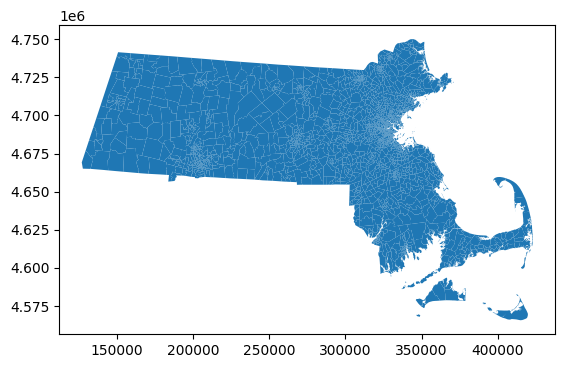

In [122]:
shapefile_path = "./{}/{}.shp".format(state_ab, state_ab)
shape=gpd.read_file(shapefile_path)
shape.plot()

In [123]:
print(list(election_df.columns))

['WP_NAME20', 'WARD20', 'COUNTY', 'PRECINCT20', 'DISTRICT20', 'TOWN20', 'TOWN_ID20', 'CD', 'SEND', 'HDIST', 'TOTPOP', 'NH_2MORE', 'NH_AMIN', 'NH_ASIAN', 'NH_BLACK', 'NH_NHPI', 'NH_OTHER', 'NH_WHITE', 'HISP', 'H_AMIN', 'H_ASIAN', 'H_BLACK', 'H_NHPI', 'H_OTHER', 'H_WHITE', 'H_2MORE', 'VAP', 'HVAP', 'WVAP', 'BVAP', 'AMINVAP', 'ASIANVAP', 'NHPIVAP', 'OTHERVAP', '2MOREVAP', 'ATG18D', 'ATG18O', 'ATG18R', 'AUD18D', 'AUD18O', 'AUD18R', 'GOV18D', 'GOV18O', 'GOV18R', 'PRE16D', 'PRE16O', 'PRE16R', 'PRE20D', 'PRE20O', 'PRE20R', 'SOC18D', 'SOC18O', 'SOC18R', 'TRE18D', 'TRE18O', 'TRE18R', 'USS18D', 'USS18O', 'USS18R', 'USS20D', 'USS20O', 'USS20R', 'geometry']


In [124]:
len(election_df.columns)


63